# 04 — Business Insights

**Objetivo:** Traduzir os dados em métricas e conclusões acionáveis para o negócio.

**KPIs analisados:**
- Receita total, ticket médio e volume de pedidos
- Taxa de itens faltando
- Top 10 produtos mais vendidos
- Receita e pedidos por região
- Ticket médio por faixa etária de cliente

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.visualization import bar_chart

master      = pd.read_parquet("../data/processed/master.parquet")
products    = pd.read_parquet("../data/processed/products.parquet")
order_items = pd.read_parquet("../data/processed/order_items.parquet")

sns.set_theme(style="whitegrid")
print(f"Dados carregados: {master.shape[0]:,} pedidos")

Dados carregados: 10,000 pedidos


## 1. KPIs executivos

In [2]:
kpis = {
    "Total de Pedidos":        f"{master.shape[0]:,}",
    "Receita Total":           f"${master['order_amount'].sum():,.0f}",
    "Ticket Médio":            f"${master['order_amount'].mean():,.2f}",
    "Taxa de Itens Faltando":  f"{master['has_missing'].mean()*100:.1f}%",
    "Total de Clientes":       f"{master['customer_id'].nunique():,}",
    "Total de Motoristas":     f"{master['driver_id'].nunique():,}",
    "Regiões Atendidas":       f"{master['region'].nunique()}",
}

print("=" * 40)
print("         RESUMO DO NEGÓCIO")
print("=" * 40)
for k, v in kpis.items():
    print(f"  {k:<28} {v}")
print("=" * 40)

         RESUMO DO NEGÓCIO
  Total de Pedidos             10,000
  Receita Total                $2,833,022
  Ticket Médio                 $283.30
  Taxa de Itens Faltando       15.0%
  Total de Clientes            1,239
  Total de Motoristas          1,247
  Regiões Atendidas            7


## 2. Receita e volume de pedidos por região

In [3]:
region_summary = (
    master.groupby("region")
    .agg(
        total_orders=("order_id", "count"),
        total_revenue=("order_amount", "sum"),
        avg_ticket=("order_amount", "mean"),
        missing_rate=("has_missing", "mean"),
    )
    .round(2)
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

region_summary["missing_rate"] = (region_summary["missing_rate"] * 100).round(1).astype(str) + "%"
region_summary["total_revenue"] = region_summary["total_revenue"].apply(lambda x: f"${x:,.0f}")
region_summary["avg_ticket"]    = region_summary["avg_ticket"].apply(lambda x: f"${x:,.2f}")

display(region_summary)

,region,total_orders,total_revenue,avg_ticket,missing_rate
0,Sanford,1461,"$420,210",$287.62,14.0%
1,Winter Park,1485,"$419,550",$282.53,14.0%
2,Altamonte Springs,1426,"$408,562",$286.51,16.0%
3,Apopka,1422,"$405,920",$285.46,15.0%
4,Orlando,1401,"$396,044",$282.69,15.0%
5,Kissimmee,1421,"$392,063",$275.91,14.0%
6,Clermont,1384,"$390,673",$282.28,16.0%


## 3. Top 10 produtos mais pedidos

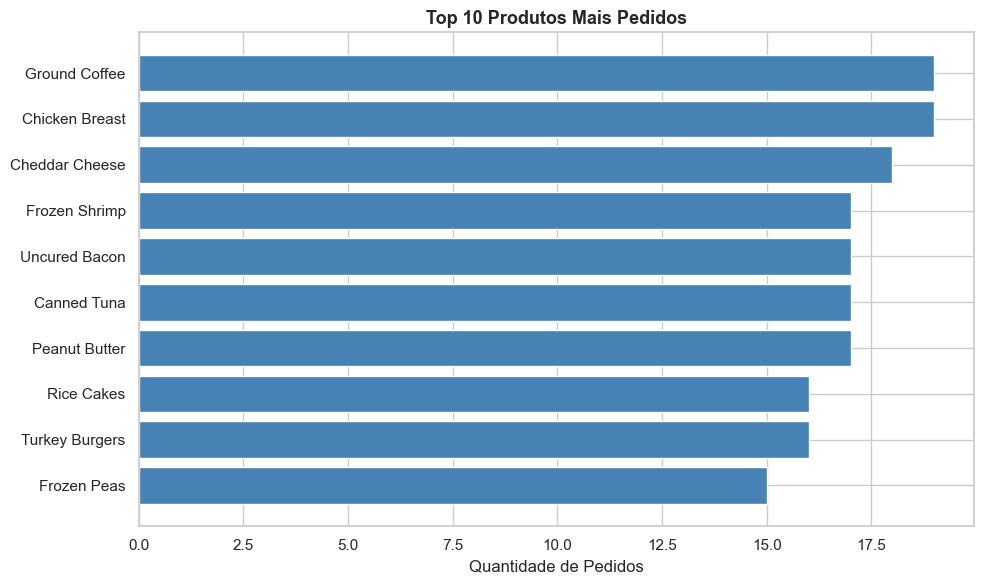

,product_name,category,order_count
0,Ground Coffee,Supermarket,19
1,Chicken Breast,Supermarket,19
2,Cheddar Cheese,Supermarket,18
3,Frozen Shrimp,Supermarket,17
4,Uncured Bacon,Supermarket,17
5,Canned Tuna,Supermarket,17
6,Peanut Butter,Supermarket,17
7,Rice Cakes,Supermarket,16
8,Turkey Burgers,Supermarket,16
9,Frozen Peas,Supermarket,15


In [4]:
top_products = (
    order_items
    .merge(products[["product_id", "product_name", "category", "price"]], on="product_id", how="left")
    .groupby(["product_name", "category"])
    .size()
    .reset_index(name="order_count")
    .sort_values("order_count", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_products["product_name"][::-1], top_products["order_count"][::-1], color="steelblue")
ax.set_title("Top 10 Produtos Mais Pedidos", fontsize=13, fontweight="bold")
ax.set_xlabel("Quantidade de Pedidos")
plt.tight_layout()
plt.savefig("../reports/figures/07_top_products.png", dpi=150)
plt.show()

display(top_products.reset_index(drop=True))

## 4. Ticket médio por faixa etária

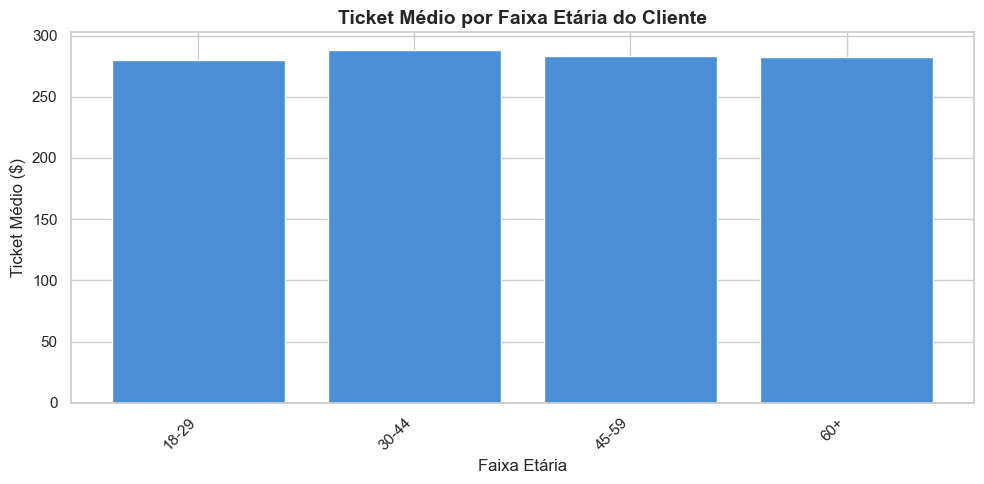

,age_group,avg_ticket
0,18-29,$280.25
1,30-44,$288.27
2,45-59,$283.16
3,60+,$282.22


In [5]:
age_bins   = [18, 30, 45, 60, 100]
age_labels = ["18-29", "30-44", "45-59", "60+"]

master["age_group"] = pd.cut(master["customer_age"], bins=age_bins, labels=age_labels, right=False)

ticket_by_age = (
    master.groupby("age_group", observed=True)["order_amount"]
    .mean()
    .reset_index()
    .rename(columns={"order_amount": "avg_ticket"})
)

fig = bar_chart(
    ticket_by_age, x="age_group", y="avg_ticket",
    title="Ticket Médio por Faixa Etária do Cliente",
    xlabel="Faixa Etária", ylabel="Ticket Médio ($)", color="#4a90d9"
)
fig.savefig("../reports/figures/08_ticket_by_age.png", dpi=150)
plt.show()

display(ticket_by_age.assign(avg_ticket=ticket_by_age["avg_ticket"].apply(lambda x: f"${x:.2f}")))